**TFIDF Introduction:**

In information retrieval, tf–idf or TFIDF, short for term frequency–inverse document frequency, is a numerical statistic that is intended to reflect how important a word is to a document in a collection or corpus.

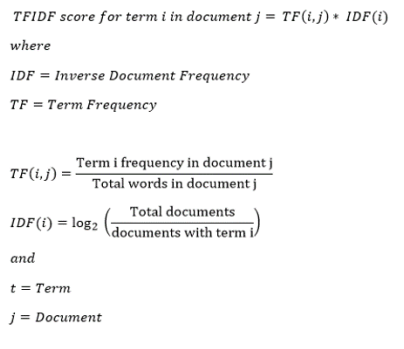

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/test_tweet.csv
/kaggle/input/train_tweet.csv


In [2]:
from nltk import pos_tag, word_tokenize
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.classification import accuracy_score, confusion_matrix
import pickle
from imblearn.over_sampling import SMOTE
from keras.utils import np_utils
import nltk
from collections import Counter
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import words
import keras
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import Flatten
from keras.layers import Embedding
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, Dropout, Activation
from keras.layers import LSTM

Using TensorFlow backend.


In [ ]:
test = pd.read_csv("./dataset/test_tweet.csv")
df = pd.read_csv("./dataset/train_tweet.csv")

In [4]:
df.head(1)

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...


In [5]:
contraction_mapping = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",

                           "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",

                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",

                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",

                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",

                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",

                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",

                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",

                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",

                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",

                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",

                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",

                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",

                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",

                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",

                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",

                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",

                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",

                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",

                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",

                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",

                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",

                           "you're": "you are", "you've": "you have"}


**Considering accuracy, precision, recall and f1 score to validate my model**

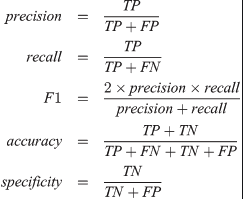

In [6]:
def cleansing(x):
    quoteRemoval = x.replace('"','')
    spaceRemoval = re.sub("\s\s+" , " ", quoteRemoval)
    stringRemoval = spaceRemoval.strip()
    urlRemove = re.sub(r'http\S+', '', stringRemoval)
    contract = ' '.join([contraction_mapping[t] if t in contraction_mapping else t for t in urlRemove.split()]) 
    specialChar = re.sub(r"[^a-zA-Z]+", ' ',urlRemove)
    stop = set(stopwords.words('english')) #to remove stop words like is,the,that etc
    stpwords = ' '.join([i for i in specialChar.lower().split() if i not in stop])
    stemmer = WordNetLemmatizer() # steaming is to remove all ing,ly etc ex: stem('playing') = play
    steming = ' '.join([stemmer.lemmatize(i) for i in stpwords.lower().split()])
    lengthy = ' '.join([i for i in steming.lower().split() if len(i.strip())>3])   
    return lengthy

def recall_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

def precision_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))


df['Cleansed'] = df['tweet'].apply(cleansing)
test['Cleansed'] = test['tweet'].apply(cleansing)

Assumption 
* max_features = 2472 (wordcount > 5)

2472


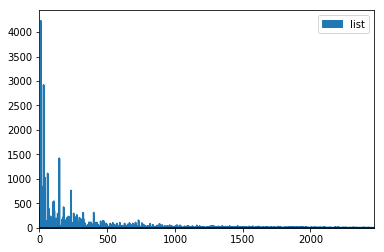

In [7]:
wordcount = []
for i in df['Cleansed'].tolist():
    for x in i.split():
        wordcount.append(x)

pl = pd.DataFrame(columns=['list'])
pd_list =[]
for i in list(Counter(wordcount).values()):
    if i>3:
        pd_list.append(i)
pl['list'] = pd_list
pl.plot.area().axhline(5,color='k')
print(len(pd_list))

In [8]:
x = df['Cleansed'].values.reshape(-1,1)
Y = df['label'].values
TfIdf = TfidfVectorizer(max_features=2472,norm='l1',ngram_range=(1,1),stop_words='english',strip_accents='ascii',analyzer='word') #top 2000 words
tfmodel = TfIdf.fit(x.ravel()) # ravel is to 
#pickle.dump(tfmodel, open('TFIDF.pkl', 'wb'))
XX = tfmodel.transform(x.ravel())

In [9]:
s = df['label'].tolist()
from collections import Counter
print(Counter(s).keys())
print(Counter(s).values())

dict_keys([0, 1])
dict_values([5894, 2026])


In [10]:
from keras.layers import LeakyReLU
model = Sequential()
model.add(Dense(128, kernel_initializer ='glorot_uniform',input_dim=XX.shape[1]))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.20))
model.add(Dense(128, kernel_initializer ='glorot_uniform'))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.20))
model.add(Dense(output_dim = 1, kernel_initializer ='glorot_uniform', activation = 'sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer='adamax',
              metrics=['acc',f1_m,precision_m, recall_m])

es = keras.callbacks.EarlyStopping(monitor='val_f1_m', min_delta=0, patience=3, verbose=0, mode='auto', baseline=None, restore_best_weights=False)

model.summary()

model.fit(XX, Y, batch_size = 12, nb_epoch = 100,callbacks=[es],validation_split=0.2)


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:9: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(kernel_initializer="glorot_uniform", activation="sigmoid", units=1)`
  if __name__ == '__main__':
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:18: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 128)               316544    
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 128)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               16512     
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 128)               0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                

In [11]:
X_test = tfmodel.transform(test['Cleansed'].values)
pred = model.predict(X_test)

In [12]:
test['label'] = [round(i[0]) for i in pred.tolist()]
test[['id','label']].to_csv('TFIDF.csv',header=True,index=False)